In [1]:
!pip install -q catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Imbalance handling
from imblearn.over_sampling import RandomOverSampler, SMOTENC, ADASYN

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Hyperparameter tuning
from scipy.stats import randint, uniform

# Interpretability
import shap

# Data
df = pd.read_csv('/content/drive/MyDrive/final_year_project/Data/fraud_oracle_clean.csv')

Mounted at /content/drive


In [3]:
# Separate features and target
X = df.drop(columns='FraudFound_P')
y = df['FraudFound_P']

# 80/20 split, keeping the fraud ratio balanced (stratify)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

# Print shapes and verify the fraud rate matches
print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_test_raw:  {X_test_raw.shape}")
print(f"y_train fraud rate: {y_train.mean():.4f}")
print(f"y_test fraud rate:  {y_test.mean():.4f}")



X_train_raw: (12335, 48)
X_test_raw:  (3084, 48)
y_train fraud rate: 0.0598
y_test fraud rate:  0.0600


## Shared utility (functions, used throughout)

In [4]:
# Group columns for specific preprocessing
TARGET_ENCODE_COLS = [
    'Make', 'AccidentArea', 'PolicyType',
    'Fault_PolicyType', 'Area_PolicyType'
]

RANGE_COLS = [
    'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim',
    'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
    'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars'
]

# Setup 5-fold cross-validation
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate ratio of negative to positive classes (useful for model class weights)
def get_weight_ratio(y):
    return (y == 0).sum() / (y == 1).sum()

def encode_dataset(X_train, X_test, y_train):
    X_tr, X_te = X_train.copy(), X_test.copy()
    global_mean = y_train.mean()

    # Target encode (replace category with its average fraud rate)
    for col in TARGET_ENCODE_COLS:
        means = y_train.groupby(X_tr[col]).mean()
        X_tr[f'{col}_te'] = X_tr[col].map(means)
        # Handle unseen categories in the test set using the global average
        X_te[f'{col}_te'] = X_te[col].map(means).fillna(global_mean)

    # Drop the original columns we just encoded and the range columns
    X_tr = X_tr.drop(columns=TARGET_ENCODE_COLS + RANGE_COLS)
    X_te = X_te.drop(columns=TARGET_ENCODE_COLS + RANGE_COLS)

    # Convert any remaining text categories into numeric IDs
    cat_cols = X_tr.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        cats = sorted(X_tr[col].dropna().unique())
        mapping = {c: i for i, c in enumerate(cats)}
        X_tr[col] = X_tr[col].map(mapping).astype(int)
        X_te[col] = X_te[col].map(mapping).fillna(-1).astype(int)

    return X_tr, X_te


# Apply the encoding function to the raw data
X_train_enc, X_test_enc = encode_dataset(X_train_raw, X_test_raw, y_train)


print(f"Encoded training set : {X_train_enc.shape}")
print(f"Encoded test set     : {X_test_enc.shape}")
print(f"Remaining object cols: {X_train_enc.select_dtypes('object').shape[1]} (should be 0)")
print(f"Nulls in train enc   : {X_train_enc.isnull().sum().sum()} (should be 0)")


# Helper function to initialise different ML models with built-in class balancing
def make_model(name, params, y_tr):
    w = get_weight_ratio(y_tr)
    builders = {
        'Logistic Regression': lambda: LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ),
        'LightGBM': lambda: LGBMClassifier(
            **params, scale_pos_weight=w, verbose=-1, random_state=42
        ),
        'XGBoost': lambda: XGBClassifier(
            **params, scale_pos_weight=w, eval_metric='logloss',
            verbosity=0, random_state=42
        ),
        'CatBoost': lambda: CatBoostClassifier(
            **params, auto_class_weights='Balanced', verbose=0, random_state=42
        ),
    }
    return builders[name]()


# Run K-Fold cross-validation and calculate evaluation metrics
def run_cv(name, params, sampler=None, X=None, y=None, verbose=True):
    if X is None:
        X = X_train_enc
    if y is None:
        y = y_train

    # Setup dictionary to store scores for each fold
    metrics = {m: [] for m in ['auc_roc', 'pr_auc', 'f1', 'precision', 'recall']}

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # Apply data resampling (like ADASYN) only to the training folds to avoid data leakage
        if sampler is not None:
            X_tr, y_tr = sampler.fit_resample(X_tr, y_tr)

        # Train the model and make predictions on the validation fold
        model = make_model(name, params, y_tr)
        model.fit(X_tr, y_tr)

        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred  = model.predict(X_val)

        # Record metrics for this fold
        metrics['auc_roc'].append(roc_auc_score(y_val, y_proba))
        metrics['pr_auc'].append(average_precision_score(y_val, y_proba))
        metrics['f1'].append(f1_score(y_val, y_pred))
        metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_val, y_pred))

        if verbose:
            print(f"  Fold {fold}: AUC={metrics['auc_roc'][-1]:.4f}  "
                  f"PR-AUC={metrics['pr_auc'][-1]:.4f}  F1={metrics['f1'][-1]:.4f}  "
                  f"Prec={metrics['precision'][-1]:.4f}  Rec={metrics['recall'][-1]:.4f}")

    # Return the mean and standard deviation for each metric across all folds
    return {m: {'mean': np.mean(v), 'std': np.std(v)} for m, v in metrics.items()}


# function to print a clean summary table of the cross-validation results
def print_summary(title, results, metrics=('auc_roc', 'pr_auc', 'f1', 'recall')):
    labels = {'auc_roc': 'AUC-ROC', 'pr_auc': 'PR-AUC', 'f1': 'F1',
              'precision': 'Precision', 'recall': 'Recall'}
    header = [f"{labels[m]:>14s}" for m in metrics]
    max_name = max(len(n) for n in results)

    print(f"\n{'=' * 55}")
    print(title)
    print(f"{'=' * 55}")
    print(f"{'Name':<{max_name}s} {''.join(header)}")
    print("-" * (max_name + 14 * len(metrics) + 2))

    for name, r in results.items():
        vals = '  '.join(f"{r[m]['mean']:.4f}±{r[m]['std']:.3f}" for m in metrics)
        print(f"{name:<{max_name}s} {vals}")

Encoded training set : (12335, 39)
Encoded test set     : (3084, 39)
Remaining object cols: 0 (should be 0)
Nulls in train enc   : 0 (should be 0)


## Baseline Model Evaluation

In [6]:
# Define the baseline models we want to evaluate
BASELINE_MODELS = {
    'Logistic Regression': {},
    'XGBoost':             {},
    'LightGBM':            {},
    'CatBoost':            {},
}

# Dictionary to store the evaluation scores
baseline_results = {}

# Loop through each model, run cross-validation, and save its results
for name, params in BASELINE_MODELS.items():
    print(f"\n{'=' * 55}\n{name}\n{'=' * 55}")
    baseline_results[name] = run_cv(name, params)

# Display a clean comparison table of all models
print_summary("BASELINE COMPARISON SUMMARY", baseline_results)

# Identify and print the best performing model based on F1 Score
best_f1 = max(baseline_results, key=lambda m: baseline_results[m]['f1']['mean'])
print(f"\nBest by F1 Score: {best_f1} ({baseline_results[best_f1]['f1']['mean']:.4f})")


Logistic Regression
  Fold 1: AUC=0.7432  PR-AUC=0.1389  F1=0.1807  Prec=0.1043  Rec=0.6757
  Fold 2: AUC=0.7448  PR-AUC=0.1467  F1=0.1799  Prec=0.1048  Rec=0.6351
  Fold 3: AUC=0.7248  PR-AUC=0.1318  F1=0.1720  Prec=0.1000  Rec=0.6149
  Fold 4: AUC=0.7273  PR-AUC=0.1270  F1=0.1780  Prec=0.1043  Rec=0.6054
  Fold 5: AUC=0.7464  PR-AUC=0.1551  F1=0.1959  Prec=0.1143  Rec=0.6871

XGBoost
  Fold 1: AUC=0.8183  PR-AUC=0.2167  F1=0.2102  Prec=0.1892  Rec=0.2365
  Fold 2: AUC=0.8396  PR-AUC=0.2234  F1=0.2620  Prec=0.2485  Rec=0.2770
  Fold 3: AUC=0.8296  PR-AUC=0.2371  F1=0.2838  Prec=0.2774  Rec=0.2905
  Fold 4: AUC=0.8303  PR-AUC=0.2273  F1=0.2662  Prec=0.2671  Rec=0.2653
  Fold 5: AUC=0.8320  PR-AUC=0.2749  F1=0.3197  Prec=0.2965  Rec=0.3469

LightGBM
  Fold 1: AUC=0.8214  PR-AUC=0.2386  F1=0.2481  Prec=0.1729  Rec=0.4392
  Fold 2: AUC=0.8380  PR-AUC=0.2268  F1=0.2863  Prec=0.1984  Rec=0.5135
  Fold 3: AUC=0.8388  PR-AUC=0.2390  F1=0.2793  Prec=0.1928  Rec=0.5068
  Fold 4: AUC=0.8244  PR

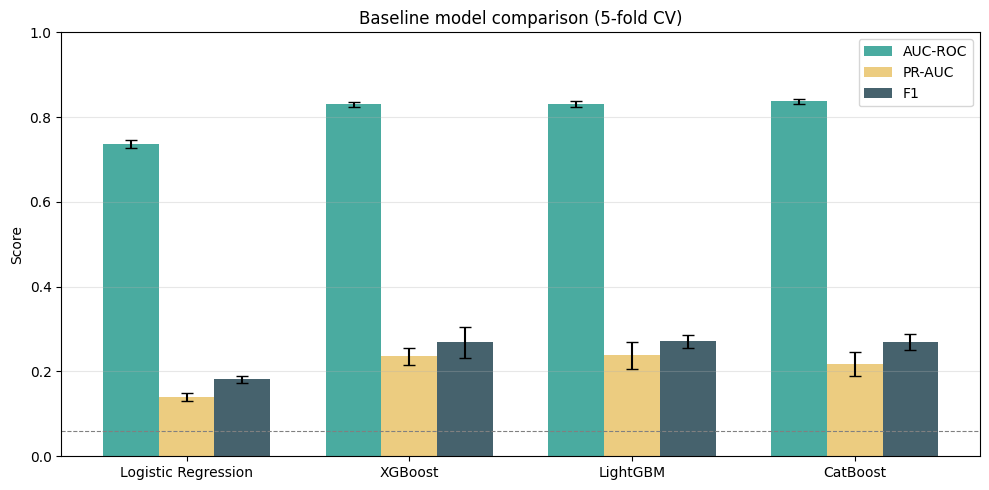

In [7]:
TEAL  = '#2A9D8F'
AMBER = '#E9C46A'
DARK  = '#264653'

# model names and which metrics to plot
model_names     = list(baseline_results.keys())
metrics_to_plot = ['auc_roc', 'pr_auc', 'f1']
labels          = ['AUC-ROC', 'PR-AUC', 'F1']
colours         = [TEAL, AMBER, DARK]


x     = np.arange(len(model_names))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

# Loop through each metric to draw a set of bars across all models
for i, (metric, label, colour) in enumerate(zip(metrics_to_plot, labels, colours)):
    # Extract the mean and standard deviation for the current metric
    means = [baseline_results[m][metric]['mean'] for m in model_names]
    stds  = [baseline_results[m][metric]['std']  for m in model_names]

    # Plot the bars with error bars (yerr) showing the standard deviation
    ax.bar(x + i * width, means, width, label=label, color=colour,
           alpha=0.85, yerr=stds, capsize=4)


ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Baseline model comparison (5-fold CV)')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.06, linestyle='--', color='gray', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Imbalance Handling (Resampling)

In [8]:
# Isolate categorical columns by filtering out numerical suffixes and specific numeric features
cat_col_names = [
    col for col in X_train_enc.columns
    if not col.endswith('_te')
    and not col.endswith('_num')
    and col not in ['ClaimDelay', 'PriceToDeductibleRatio',
                    'AgeWasZero', 'Age', 'Deductible', 'DriverRating']
]

# Get the exact column indices for these categorical features (required by SMOTENC)
cat_col_indices = [X_train_enc.columns.get_loc(col) for col in cat_col_names]

print(f"Categorical columns for SMOTENC: {len(cat_col_indices)}")

# Define the different techniques to handle our imbalanced dataset
RESAMPLING_STRATEGIES = {
    'Class weights (baseline)': None,
    'RandomOverSampler':        RandomOverSampler(random_state=42),
    'SMOTENC':                  SMOTENC(categorical_features=cat_col_indices, random_state=42),
    'ADASYN':                   ADASYN(random_state=42),
}

# Dictionary to store the evaluation scores for each resampling method
resampling_results = {}

# Test each resampling strategy using LightGBM as the base model
for strategy_name, sampler in RESAMPLING_STRATEGIES.items():
    # Print a visual separator for console readability
    print(f"\n{'=' * 55}\nLightGBM + {strategy_name}\n{'=' * 55}")
    resampling_results[strategy_name] = run_cv('LightGBM', {}, sampler=sampler)

# Display a clean comparison table of all resampling methods
print_summary("RESAMPLING COMPARISON SUMMARY (LightGBM)", resampling_results)

# Extract and print the best performing strategies based on different metrics
best_f1  = max(resampling_results, key=lambda s: resampling_results[s]['f1']['mean'])
best_pr  = max(resampling_results, key=lambda s: resampling_results[s]['pr_auc']['mean'])
best_rec = max(resampling_results, key=lambda s: resampling_results[s]['recall']['mean'])

print(f"\nBest by F1     : {best_f1} ({resampling_results[best_f1]['f1']['mean']:.4f})")
print(f"Best by PR-AUC : {best_pr} ({resampling_results[best_pr]['pr_auc']['mean']:.4f})")
print(f"Best by Recall : {best_rec} ({resampling_results[best_rec]['recall']['mean']:.4f})")

Categorical columns for SMOTENC: 19

LightGBM + Class weights (baseline)
  Fold 1: AUC=0.8214  PR-AUC=0.2386  F1=0.2481  Prec=0.1729  Rec=0.4392
  Fold 2: AUC=0.8380  PR-AUC=0.2268  F1=0.2863  Prec=0.1984  Rec=0.5135
  Fold 3: AUC=0.8388  PR-AUC=0.2390  F1=0.2793  Prec=0.1928  Rec=0.5068
  Fold 4: AUC=0.8244  PR-AUC=0.1933  F1=0.2597  Prec=0.1786  Rec=0.4762
  Fold 5: AUC=0.8323  PR-AUC=0.2936  F1=0.2857  Prec=0.1929  Rec=0.5510

LightGBM + RandomOverSampler
  Fold 1: AUC=0.8135  PR-AUC=0.2417  F1=0.2467  Prec=0.1630  Rec=0.5068
  Fold 2: AUC=0.8412  PR-AUC=0.2276  F1=0.2801  Prec=0.1978  Rec=0.4797
  Fold 3: AUC=0.8346  PR-AUC=0.2268  F1=0.2761  Prec=0.1871  Rec=0.5270
  Fold 4: AUC=0.8477  PR-AUC=0.2311  F1=0.3164  Prec=0.2188  Rec=0.5714
  Fold 5: AUC=0.8355  PR-AUC=0.2778  F1=0.2877  Prec=0.1930  Rec=0.5646

LightGBM + SMOTENC
  Fold 1: AUC=0.8214  PR-AUC=0.2648  F1=0.2069  Prec=0.3818  Rec=0.1419
  Fold 2: AUC=0.8334  PR-AUC=0.2586  F1=0.2222  Prec=0.3898  Rec=0.1554
  Fold 3: AUC

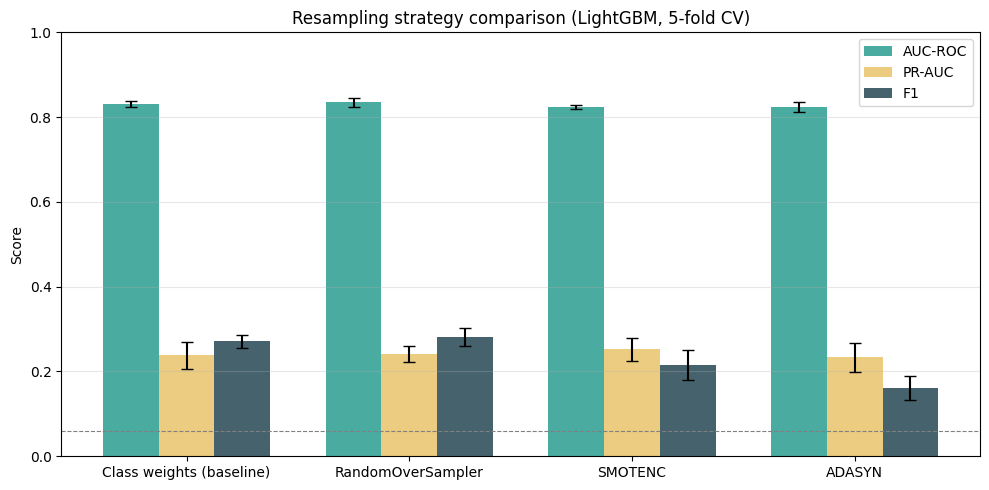

In [11]:
# Reuse the custom hex colors (just in case they aren't loaded in this cell)
TEAL  = '#2A9D8F'
AMBER = '#E9C46A'
DARK  = '#264653'

# Extract the resampling strategy names and define which metrics to plot
strategy_names  = list(resampling_results.keys())
metrics_to_plot = ['auc_roc', 'pr_auc', 'f1']
labels          = ['AUC-ROC', 'PR-AUC', 'F1']
colours         = [TEAL, AMBER, DARK]

# Set up the base positions and width for grouped bars
x     = np.arange(len(strategy_names))
width = 0.25

# Initialise the plot figure
fig, ax = plt.subplots(figsize=(10, 5))

# Loop through each metric to draw a set of bars across all strategies
for i, (metric, label, colour) in enumerate(zip(metrics_to_plot, labels, colours)):
    # Extract the mean and standard deviation for the current metric
    means = [resampling_results[s][metric]['mean'] for s in strategy_names]
    stds  = [resampling_results[s][metric]['std']  for s in strategy_names]

    # Plot the bars with error bars showing the standard deviation
    ax.bar(x + i * width, means, width, label=label, color=colour,
           alpha=0.85, yerr=stds, capsize=4)

# Format the x-axis to center the labels under each group of bars
ax.set_xticks(x + width)
ax.set_xticklabels(strategy_names, fontsize=10)

# Add standard chart labels and title
ax.set_ylabel('Score')
ax.set_title('Resampling strategy comparison (LightGBM, 5-fold CV)')
ax.legend()

# Set y-axis limits to represent percentages (0 to 1)
ax.set_ylim(0, 1)

# Draw a horizontal line at 0.06 (likely representing the base fraud rate)
ax.axhline(0.06, linestyle='--', color='gray', linewidth=0.8)

# Add faint horizontal grid lines for readability
ax.grid(axis='y', alpha=0.3)

# Clean up layout padding and display the chart
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [12]:
# Define the hyperparameter ranges we want to test for each model
search_spaces = {
    'LightGBM': {
        'model': LGBMClassifier(
            scale_pos_weight=get_weight_ratio(y_train),
            verbose=-1, random_state=42
        ),
        'params': {
            'n_estimators': randint(100, 500), 'max_depth': randint(3, 12),
            'learning_rate': uniform(0.01, 0.29), 'num_leaves': randint(20, 100),
            'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4),
            'min_child_samples': randint(5, 50),
            'reg_alpha': uniform(0, 5), 'reg_lambda': uniform(0, 5),
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            scale_pos_weight=get_weight_ratio(y_train),
            eval_metric='logloss', verbosity=0, random_state=42
        ),
        'params': {
            'n_estimators': randint(100, 500), 'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.29),
            'subsample': uniform(0.6, 0.4), 'colsample_bytree': uniform(0.6, 0.4),
            'gamma': uniform(0, 5), 'min_child_weight': randint(1, 10),
            'reg_alpha': uniform(0, 5), 'reg_lambda': uniform(0, 5),
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            auto_class_weights='Balanced', verbose=0, random_state=42
        ),
        'params': {
            'iterations': randint(100, 500), 'depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.29), 'l2_leaf_reg': uniform(1, 9),
            'border_count': randint(32, 255), 'random_strength': uniform(0, 10),
            'bagging_temperature': uniform(0, 10),
        }
    },
}

tuning_results = {}



In [16]:
# HYPERPARAMETER TUNING: Find the best settings for each model and pick the ultimate winner
for model_name, config in search_spaces.items():
    print(f"Tuning {model_name}...")

    # Run 30 random searches per model to optimise PR-AUC (Average Precision)
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=30, scoring='average_precision',
        cv=CV, random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train_enc, y_train)

    # Store the winning parameters for this specific model
    tuning_results[model_name] = {
        'best_params': search.best_params_,
        'best_pr_auc': search.best_score_,
    }
    print(f"  Best CV PR-AUC: {search.best_score_:.4f}")
    print(f"  Best params:    {search.best_params_}\n")

# Run full cross-validation on all models using their new optimised settings
evaluated = {}
for name, result in tuning_results.items():
    print(f"\n{'=' * 55}\n{name} (tuned)\n{'=' * 55}")
    evaluated[name] = run_cv(name, result['best_params'])

print_summary("TUNED MODEL SUMMARY", evaluated)

# Select the "Champion" model based on the highest F1 Score
champion_name   = max(evaluated, key=lambda m: evaluated[m]['f1']['mean'])
champion_params = tuning_results[champion_name]['best_params']
print(f"\nChampion by F1: {champion_name} ({evaluated[champion_name]['f1']['mean']:.4f})")

# Final Shootout: Check if the champion performs better with internal weights or ROS resampling
print(f"\n{'=' * 55}")
print(f"CHAMPION ({champion_name}) — CLASS WEIGHTS vs ROS")
print(f"{'=' * 55}")

champ_cw  = run_cv(champion_name, champion_params)
champ_ros = run_cv(champion_name, champion_params,
                   sampler=RandomOverSampler(random_state=42))

champ_comparison = {
    f'{champion_name} + Class weights': champ_cw,
    f'{champion_name} + ROS':           champ_ros,
}
print_summary(" FINAL SUMMARY", champ_comparison)

# Determine if ROS improved the champion and set the final model configuration
champion_ros  = champ_ros['f1']['mean'] >= champ_cw['f1']['mean']
final_results = champ_ros if champion_ros else champ_cw
final_config  = f"{champion_name} (tuned) + {'ROS' if champion_ros else 'Class weights'}"
print(f"\nFinal champion: {final_config}")

Tuning LightGBM...
  Best CV PR-AUC: 0.2485
  Best params:    {'colsample_bytree': np.float64(0.8603553891795411), 'learning_rate': np.float64(0.026359357917859073), 'max_depth': 10, 'min_child_samples': 48, 'n_estimators': 393, 'num_leaves': 21, 'reg_alpha': np.float64(0.9091248360355031), 'reg_lambda': np.float64(0.9170225492671691), 'subsample': np.float64(0.7216968971838151)}

Tuning XGBoost...
  Best CV PR-AUC: 0.2627
  Best params:    {'colsample_bytree': np.float64(0.8363571772752967), 'gamma': np.float64(3.3878218092114123), 'learning_rate': np.float64(0.014810470389078283), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 247, 'reg_alpha': np.float64(3.2258639520472494), 'reg_lambda': np.float64(0.8718321450249572), 'subsample': np.float64(0.8763750952409863)}

Tuning CatBoost...
  Best CV PR-AUC: 0.2255
  Best params:    {'bagging_temperature': np.float64(9.65255307264138), 'border_count': 219, 'depth': 6, 'iterations': 140, 'l2_leaf_reg': np.float64(3.6664615513367416)

In [17]:
# Save tuning results
with open('/content/drive/MyDrive/final_year_project/models/tuning_results.pkl', 'wb') as f:
    pickle.dump({
        'champion_name':   champion_name,
        'champion_params': champion_params,
        'champion_ros':    champion_ros,
        'tuning_results':  tuning_results,
        'evaluated':       evaluated,
    }, f)

print("\nTuning results saved")


Tuning results saved


In [27]:
# RELOAD BLOCK
# ------------------------------------------------------------
# with open('/content/drive/MyDrive/final_year_project/models/tuning_results.pkl', 'rb') as f:
#     saved = pickle.load(f)
# champion_name   = saved['champion_name']
# champion_params = saved['champion_params']
# champion_ros    = saved['champion_ros']
# tuning_results  = saved['tuning_results']
# evaluated       = saved['evaluated']
# print(f"Loaded — champion: {champion_name}")

## Threshold Optimisation & Final Testing

In [18]:
# --- THRESHOLD OPTIMISATION ---

# Generate cross-validated probabilities for the training set
fold_proba = np.zeros(len(X_train_enc))

for tr_idx, val_idx in CV.split(X_train_enc, y_train):
    X_tr, X_val = X_train_enc.iloc[tr_idx], X_train_enc.iloc[val_idx]
    y_tr = y_train.iloc[tr_idx]

    # Re-train champion model on the current fold
    model = make_model(champion_name, champion_params, y_tr)
    model.fit(X_tr, y_tr)
    fold_proba[val_idx] = model.predict_proba(X_val)[:, 1]

# Test every threshold from 0.05 to 0.95 to find the best balance
thresholds = np.arange(0.05, 0.95, 0.01)
results = []

for t in thresholds:
    y_pred = (fold_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_train, y_pred, zero_division=0),
        'recall':    recall_score(y_train, y_pred),
        'f1':        f1_score(y_train, y_pred),
    })

# Convert to DataFrame and pick the threshold with the highest F1
threshold_df = pd.DataFrame(results)
best_row     = threshold_df.loc[threshold_df['f1'].idxmax()]
best_t       = round(best_row['threshold'], 2)

print(f"Best threshold : {best_t}")
print(f"F1 Score at this threshold: {best_row['f1']:.4f}")

# Display a window of results around the chosen threshold
window = threshold_df[
    (threshold_df['threshold'] >= best_t - 0.05) &
    (threshold_df['threshold'] <= best_t + 0.05)
]
print(window.to_string(index=False))

Best threshold : 0.61
F1 Score at this threshold: 0.3025
 threshold  precision   recall       f1
      0.56   0.198252 0.584011 0.296016
      0.57   0.200679 0.560976 0.295609
      0.58   0.202339 0.539295 0.294270
      0.59   0.206878 0.521680 0.296268
      0.60   0.211658 0.506775 0.298603
      0.61   0.217910 0.494580 0.302528
      0.62   0.220532 0.471545 0.300518
      0.63   0.224380 0.453930 0.300314
      0.64   0.227370 0.432249 0.297992
      0.65   0.228244 0.405149 0.291992


In [19]:
# --- FINAL TEST SET EVALUATION ---

# Train the champion model on 100% of the training data
final_model = make_model(champion_name, champion_params, y_train)
final_model.fit(X_train_enc, y_train)

# Predict on the unseen test set
test_proba = final_model.predict_proba(X_test_enc)[:, 1]
test_pred  = (test_proba >= best_t).astype(int)

# Calculate final metrics
auc   = roc_auc_score(y_test, test_proba)
prauc = average_precision_score(y_test, test_proba)
f1    = f1_score(y_test, test_pred)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(f"{'='*30}\nFINAL TEST RESULTS\n{'='*30}")
print(f"AUC-ROC: {auc:.4f} | PR-AUC: {prauc:.4f} | F1: {f1:.4f}")
print(f"Fraud Caught (Recall): {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"False Alarms: {fp}/{fp+tn} ({fp/(fp+tn)*100:.1f}%)")

# Compare our optimised threshold against the standard 0.50 default
d_f1 = f1_score(y_test, (test_proba >= 0.50).astype(int))
print(f"\nF1 improvement over default 0.50: {f1 - d_f1:+.4f}")
print(classification_report(y_test, test_pred, target_names=['Not Fraud', 'Fraud']))

FINAL TEST RESULTS
AUC-ROC: 0.8386 | PR-AUC: 0.2255 | F1: 0.2911
Fraud Caught (Recall): 100/185 (54.1%)
False Alarms: 402/2899 (13.9%)

F1 improvement over default 0.50: +0.0227
              precision    recall  f1-score   support

   Not Fraud       0.97      0.86      0.91      2899
       Fraud       0.20      0.54      0.29       185

    accuracy                           0.84      3084
   macro avg       0.58      0.70      0.60      3084
weighted avg       0.92      0.84      0.87      3084



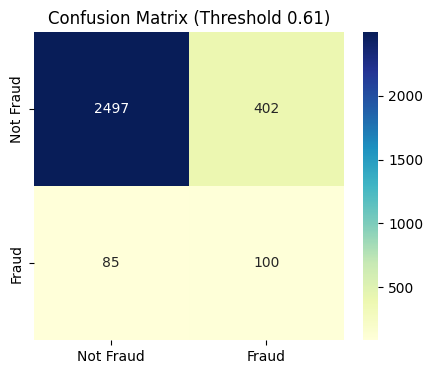

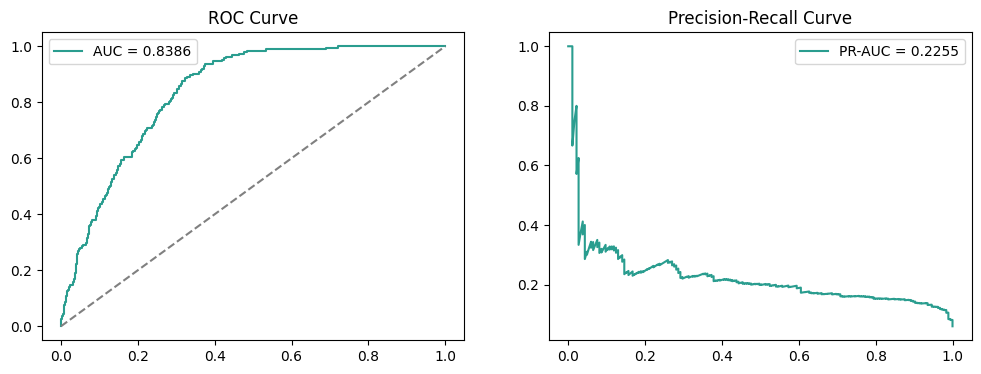

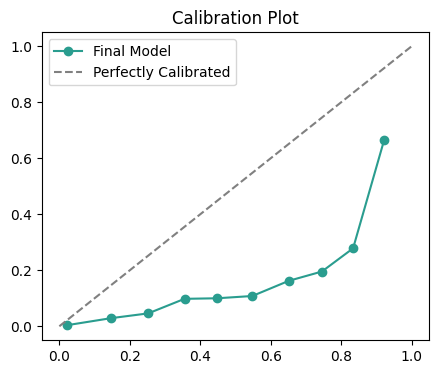

In [20]:
# --- VISUAL PERFORMANCE ANALYSIS ---

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold {best_t})')
plt.show()

# Plot ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, color=TEAL, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR Curve
p_curve, r_curve, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(r_curve, p_curve, color=TEAL, label=f'PR-AUC = {prauc:.4f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
plt.show()

# Calibration Plot - Checks if predicted % matches actual frequency
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)
plt.figure(figsize=(5, 4))
plt.plot(prob_pred, prob_true, marker='o', color=TEAL, label='Final Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.title('Calibration Plot')
plt.legend()
plt.show()

In [21]:
# --- EXPORT FINAL MODEL ---

import pickle

model_export_path = '/content/drive/MyDrive/final_year_project/models/final_model.pkl'

with open(model_export_path, 'wb') as f:
    pickle.dump({
        'final_model': final_model,
        'best_t':      best_t,
        'test_proba':  test_proba,
    }, f)

print(f"Model and settings saved successfully to: {model_export_path}")

Model and settings saved successfully to: /content/drive/MyDrive/final_year_project/models/final_model.pkl


In [28]:

# RELOAD BLOCK
# ------------------------------------------------------------
# with open('/content/drive/MyDrive/final_year_project/models/final_model.pkl', 'rb') as f:
#     saved = pickle.load(f)
# final_model = saved['final_model']
# best_t      = saved['best_t']
# test_proba  = saved['test_proba']
# test_pred   = (test_proba >= best_t).astype(int)
# print(f"Loaded — threshold: {best_t}")

## Business Cost & Fairness Analysis

In [22]:
# --- BUSINESS COST EVALUATION ---

# Financial assumptions for the impact of fraud detection
INVESTIGATION_COST = 500   # Cost of staff time to check a flagged claim
MISSED_FRAUD_COST  = 15000 # Average loss when fraud goes undetected

print(f"Cost per false alarm: £{INVESTIGATION_COST:,}")
print(f"Cost per missed fraud: £{MISSED_FRAUD_COST:,}")

# Compare different thresholds to see which one saves the most money
strategies = {
    'Default (0.50)':       0.50,
    f'Selected ({best_t})':  best_t,
    'Catch-all (0.10)':     0.10,
}

print(f"\n{'Strategy':20s} {'TP':>5s} {'FP':>6s} {'FN':>6s} {'Total Cost':>12s}")
print("-" * 55)

cost_results = {}
for name, threshold in strategies.items():
    # Apply threshold and get confusion matrix values
    y_p = (test_proba >= threshold).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, y_p).ravel()

    # Total Cost = (False Alarms * Invest. Cost) + (Missed Fraud * Fraud Cost)
    total_cost = (fp_ * INVESTIGATION_COST) + (fn_ * MISSED_FRAUD_COST)
    cost_results[name] = total_cost

    print(f"{name:20s} {tp_:5d} {fp_:6d} {fn_:6d} £{total_cost:>10,}")

# Calculate the actual money saved by using our optimised threshold
saving = cost_results['Default (0.50)'] - cost_results[f'Selected ({best_t})']
print(f"\nMoney saved vs default settings: £{saving:,}")

Cost per false alarm: £500
Cost per missed fraud: £15,000

Strategy                TP     FP     FN   Total Cost
-------------------------------------------------------
Default (0.50)         131    660     54 £ 1,140,000
Selected (0.61)        100    402     85 £ 1,476,000
Catch-all (0.10)       179   1324      6 £   752,000

Money saved vs default settings: £-336,000


In [23]:
# --- MODEL FAIRNESS CHECK (BY SEX) ---

# Create a temporary dataframe to compare predictions against demographic data
fair_df = X_test_raw[['Sex']].copy()
fair_df['actual']    = y_test.values
fair_df['predicted'] = (test_proba >= best_t).astype(int)

print(f"{'Group':8s} {'Total':>7s} {'Fraud%':>8s} {'Flagged%':>10s} {'Precision':>11s} {'Recall':>9s}")
print("-" * 60)

# Calculate metrics for each group separately
for group in sorted(fair_df['Sex'].unique()):
    g = fair_df[fair_df['Sex'] == group]

    # Manual calculation of Precision and Recall for the specific group
    tp_ = ((g['predicted'] == 1) & (g['actual'] == 1)).sum()
    fp_ = ((g['predicted'] == 1) & (g['actual'] == 0)).sum()
    fn_ = ((g['predicted'] == 0) & (g['actual'] == 1)).sum()

    prec   = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    recall = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0

    print(f"{group:8s} {len(g):7d} {g['actual'].mean():8.1%} "
          f"{g['predicted'].mean():10.1%} {prec:11.4f} {recall:9.4f}")

# Note: We look for similar Precision and Recall across groups to ensure fair treatment.

Group      Total   Fraud%   Flagged%   Precision    Recall
------------------------------------------------------------
Female       484     4.3%       9.5%      0.1304    0.2857
Male        2600     6.3%      17.5%      0.2061    0.5732


## Interpretability & SHAP

In [24]:
# --- SHAP VALUE COMPUTATION ---

print("Computing SHAP values on test set...")

# TreeExplainer is optimised specifically for tree-based models like LightGBM/XGBoost
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_enc)

print(f"SHAP values computed — test set shape: {X_test_enc.shape}")

# Create a summary table of feature importance based on mean absolute SHAP values
importance_df = pd.DataFrame({
    'feature':       X_test_enc.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# Print the top 15 features for quick reference
print(f"\n{'=' * 45}\nTOP 15 FEATURES (BY IMPACT)\n{'=' * 45}")
print(importance_df.head(15).to_string(index=False))

Computing SHAP values on test set...
SHAP values computed — test set shape: (3084, 39)

TOP 15 FEATURES (BY IMPACT)
                feature  mean_abs_shap
    Fault_PolicyType_te       1.669409
                  Fault       0.589110
                    Age       0.228587
                  Month       0.182820
              RepNumber       0.179603
                   Year       0.163432
                Make_te       0.157642
       DayOfWeekClaimed       0.116028
           MonthClaimed       0.106635
           DriverRating       0.103024
                    Sex       0.094565
NumberOfSuppliments_num       0.092144
             Deductible       0.083366
             BasePolicy       0.077498
     Area_PolicyType_te       0.076273


Generating Global Feature Importance Plot...


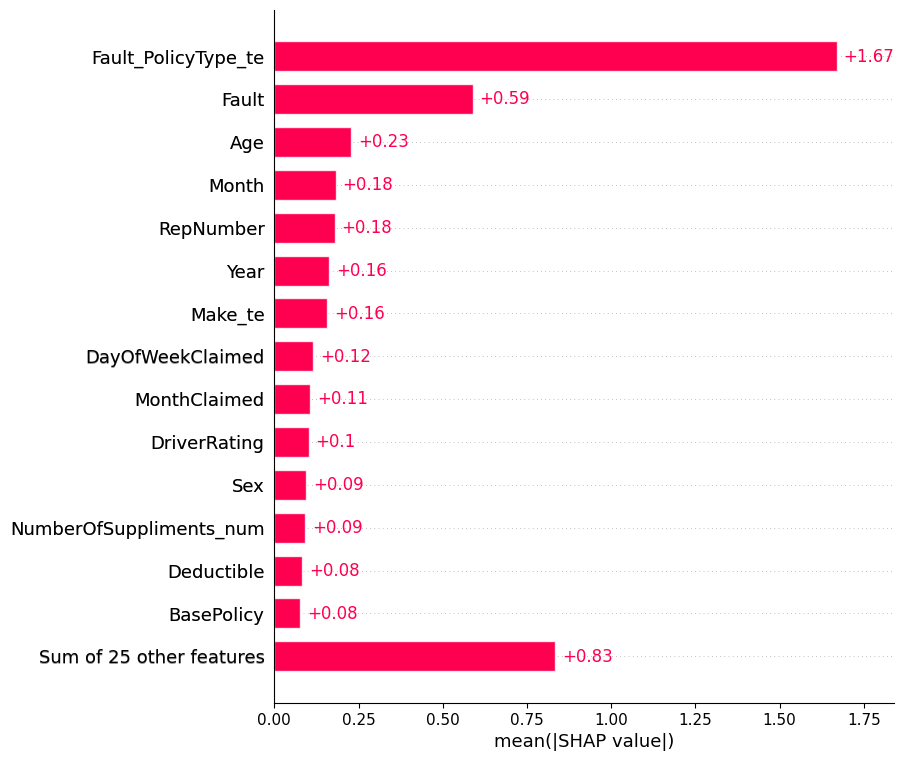

In [25]:
# --- GLOBAL FEATURE IMPORTANCE PLOT ---

# This bar plot shows "Which factors matter most for detecting fraud overall?"
print("Generating Global Feature Importance Plot...")
shap.plots.bar(shap_values, max_display=15)

# Note: Features at the top have the biggest influence on the model's final probability score.

Waterfall for most suspicious claim (Index: 1203)
Predicted Prob: 0.9424
Actual Label: FRAUD


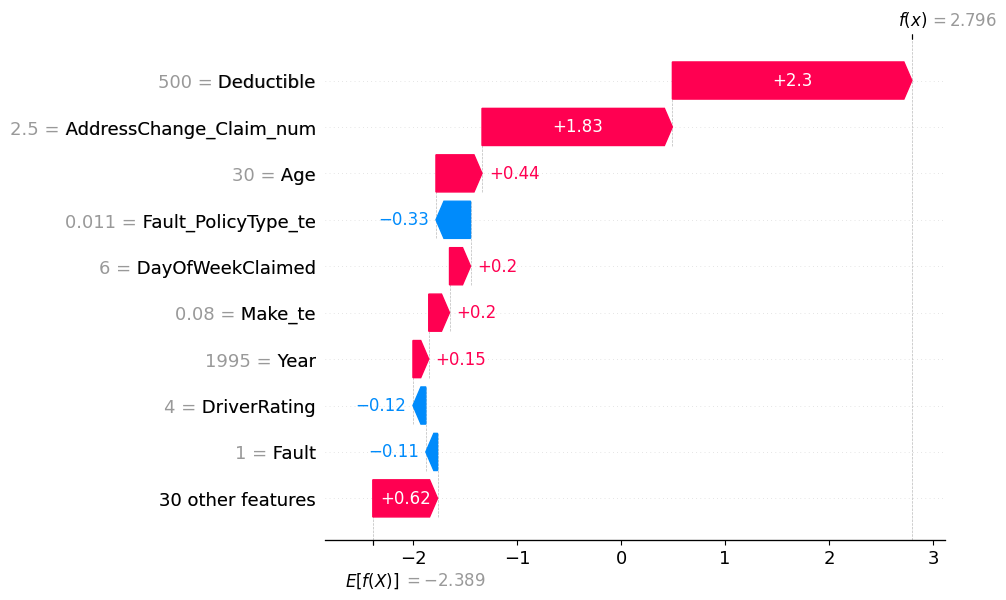


Waterfall for missed fraud case (Index: 2868)
Predicted Prob: 0.0107 (Actual: FRAUD)


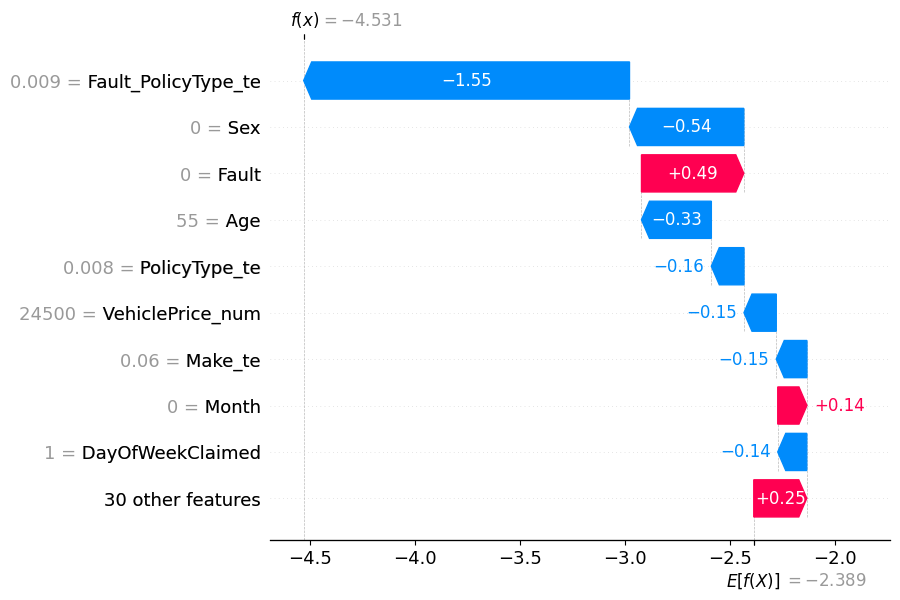

In [26]:
# --- INDIVIDUAL CASE ANALYSIS (WATERFALL PLOTS) ---

# Case 1: The most suspicious claim (highest predicted probability)
most_suspicious_idx = test_proba.argmax()
print(f"Waterfall for most suspicious claim (Index: {most_suspicious_idx})")
print(f"Predicted Prob: {test_proba[most_suspicious_idx]:.4f}")
print(f"Actual Label: {'FRAUD' if y_test.iloc[most_suspicious_idx] == 1 else 'NOT FRAUD'}")

shap.plots.waterfall(shap_values[most_suspicious_idx])

# Case 2: Analysis of a "False Negative" (Fraud that the model missed)
# We find cases where actual was 1 but prediction was 0
false_negatives = np.where((y_test.values == 1) & (test_pred == 0))[0]

if len(false_negatives) > 0:
    # We pick the one the model was most confident was "not fraud" (lowest probability)
    fn_idx = false_negatives[test_proba[false_negatives].argmin()]
    print(f"\nWaterfall for missed fraud case (Index: {fn_idx})")
    print(f"Predicted Prob: {test_proba[fn_idx]:.4f} (Actual: FRAUD)")

    shap.plots.waterfall(shap_values[fn_idx])
else:
    print("\nNo false negatives found — the model caught every fraud case in the test set.")

## Temporal Validation

In [30]:
# Create a dictionary to map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Convert Month to numbers if it isn't already
if df['Month'].dtype == 'O': # 'O' means object/string
    df['Month'] = df['Month'].map(month_map)

# Sort chronologically
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Define the training window (first 18 months: all of 1994 + first 6 months of 1995)
train_mask = (df['Year'] == 1994) | ((df['Year'] == 1995) & (df['Month'] <= 6))

X_train_temp = df[train_mask].drop(columns='FraudFound_P')
y_train_temp = df[train_mask]['FraudFound_P']

# Define the test window (months 19-24: July 1995 to Dec 1995)
test_mask = (df['Year'] == 1995) & (df['Month'] > 6)

X_test_temp = df[test_mask].drop(columns='FraudFound_P')
y_test_temp = df[test_mask]['FraudFound_P']

print(f"Training on first 18 months: {X_train_temp.shape}")
print(f"Testing on last 6 months:    {X_test_temp.shape}")

Training on first 18 months: (8761, 48)
Testing on last 6 months:    (2575, 48)


In [32]:
# 1. Encode the temporal datasets
X_tr_t_enc, X_te_t_enc = encode_dataset(X_train_temp, X_test_temp, y_train_temp)

# 2. Train the model on the 'past' (18 months)
temp_model = make_model(champion_name, champion_params, y_train_temp)
temp_model.fit(X_tr_t_enc, y_train_temp)

# 3. Predict on the 'future' (6 months) using our best threshold
t_proba = temp_model.predict_proba(X_te_t_enc)[:, 1]
t_pred  = (t_proba >= best_t).astype(int)

# 4. Results
print(f"--- TEMPORAL VALIDATION RESULTS ---")
print(classification_report(y_test_temp, t_pred))

# Check if the fraud rate in the 'future' is similar to the 'past'
print(f"Fraud rate in training: {y_train_temp.mean():.4f}")
print(f"Fraud rate in testing:  {y_test_temp.mean():.4f}")

--- TEMPORAL VALIDATION RESULTS ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2415
           1       0.57      0.05      0.09       160

    accuracy                           0.94      2575
   macro avg       0.76      0.52      0.53      2575
weighted avg       0.92      0.94      0.91      2575

Fraud rate in training: 0.0628
Fraud rate in testing:  0.0621
